In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
import lifelines
import itertools


In [38]:
lifelines.__version__

'0.25.6'

In [54]:
# specify which version to use.
## roc_definition:
### ROClast = uses the last ROC datetime (if patient has multiple ROC's)
### ROCfirst uses first
## hypoxia_timespan
### PaO2intubation: use all PaO2 values from intubation until ROC
### PaO2intubation14days: use all PaO2 values from intubation until ROC but max. 14 days after intubation
### PaO2admission: use all PaO2 values from admission until ROC

roc_definition = 'ROClast'
hypoxia_timespan = 'PaO2intubation'

In [55]:
# read in data
data = pd.read_csv(f'cohort_hypoxia_roc_{roc_definition}_{hypoxia_timespan}.csv', sep=',')

In [56]:
day_7_alive_and_comatose = False

if day_7_alive_and_comatose:
    data = data.loc[data.ROC_Day7 == 0]
    
data.shape

(336, 129)

In [57]:
[x for x in data.columns if 'ROC' in x]

['ROC_DTS',
 'ROC_Binary',
 'ROC_LOC',
 'ROC_Day7',
 'Time_To_ROC',
 '55_t_ROC',
 '70_t_ROC']

In [58]:
[x for x in data.columns if '55' in x]

['PaO2_55',
 'Cat_Days_PaO2_55',
 '55_First_DTS',
 '55_t_Admission',
 '55_t_Intubation',
 '55_t_ROC']

In [59]:
# exclusion criteria
data = data.loc[data.ROC_LOC == 1] # have to have Loss Of Consciousness

In [60]:
data.shape

(330, 129)

In [61]:
pao2_threshold = 55 # for strata

# Kaplan Meier Fitter
# kmf.fit(durations = data['Time_To_ROC'], event_observed = data['ROC_Binary'])

kmf_belowhypoxiath = KaplanMeierFitter()
kmf_abovehypoxiath = KaplanMeierFitter()

data_belowhypoxiath = data.query(f"PaO2_{pao2_threshold} == 1")
data_abovehypoxiath = data.query(f"PaO2_{pao2_threshold} == 0")

kmf_belowhypoxiath.fit(durations = data_belowhypoxiath['Time_To_ROC'], event_observed = data_belowhypoxiath['ROC_Binary'])
kmf_abovehypoxiath.fit(durations = data_abovehypoxiath['Time_To_ROC'], event_observed = data_abovehypoxiath['ROC_Binary'])

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 255 total observations, 47 right-censored observations>

/home/wolfgang/anaconda3/envs/analysis/lib/python3.6/site-packages/pandas/plotting/_matplotlib/core.py:652: MatplotlibDeprecationWarning: Saw kwargs ['c', 'color'] which are all aliases for 'color'.  Kept value from 'color'.  Passing multiple aliases for the same property will raise a TypeError in 3.3.
  return ax.plot(*args, **kwds)
/home/wolfgang/anaconda3/envs/analysis/lib/python3.6/site-packages/pandas/plotting/_matplotlib/core.py:652: MatplotlibDeprecationWarning: Saw kwargs ['c', 'color'] which are all aliases for 'color'.  Kept value from 'color'.  Passing multiple aliases for the same property will raise a TypeError in 3.3.
  return ax.plot(*args, **kwds)


Text(0, 0.5, '% Recovered')

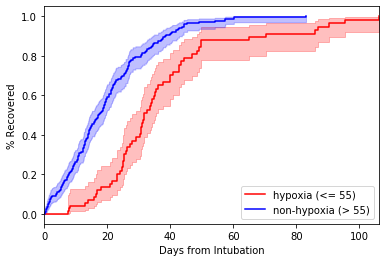

In [62]:
plt.figure()
kmf_belowhypoxiath.plot_cumulative_density(at_risk_counts=False, c='red')
kmf_abovehypoxiath.plot_cumulative_density(at_risk_counts=False, c='blue')
plt.legend([f"hypoxia (<= {pao2_threshold})", f"non-hypoxia (> {pao2_threshold})"])
plt.xlabel('Days from Intubation')
plt.ylabel('% Recovered')

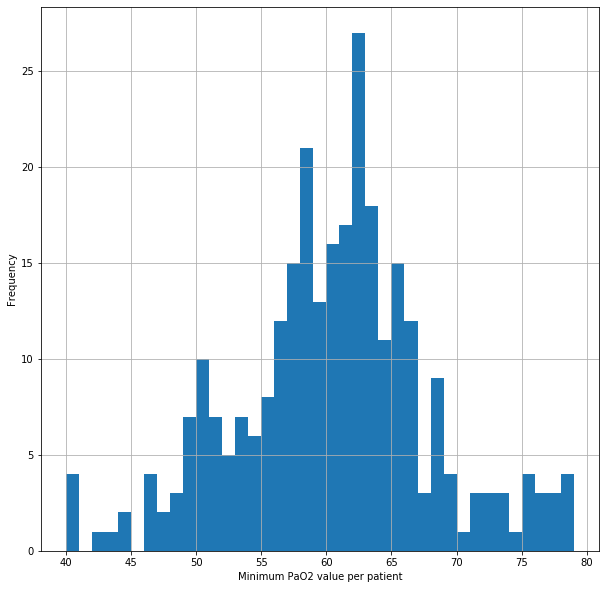

In [72]:
plt.figure(figsize=(10,10))
data.PaO2_minimum.hist(bins=np.arange(40, 80, 1))
plt.xlabel('Minimum PaO2 value per patient')
plt.ylabel('Frequency')
plt.savefig('hypoxia_covid_minimum_pao2_per_patient.svg')
plt.savefig('hypoxia_covid_minimum_pao2_per_patient.tiff')

In [74]:
for q in [0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]:
    print(f'q={q}: {data.PaO2_minimum.quantile(q).round(1)}')

q=0: 31.0
q=0.2: 54.0
q=0.4: 59.0
q=0.5: 61.0
q=0.6: 62.0
q=0.8: 68.0
q=1.0: 199.0


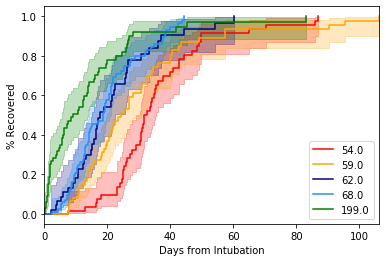

In [65]:
# plt.figure()
fig, ax = plt.subplots(1,1, figsize=(6, 4))
pao2_threshold = 55 # for strata
max_q_vals = []
color = ['red', 'orange', 'navy', 'dodgerblue', 'green']
# Kaplan Meier Fitter
# kmf.fit(durations = data['Time_To_ROC'], event_observed = data['ROC_Binary'])
for iq, q in enumerate([0.2, 0.4, 0.6, 0.8, 1]):
    
    min_q_val = data.PaO2_minimum.quantile(q - 0.2)
    max_q_val = data.PaO2_minimum.quantile(q)
    
    if q == 0.2:
        min_q_val = 0
    elif q == 1:
        max_q_val = 1000

    kmf = KaplanMeierFitter()

    data_selection = data.query(f"PaO2_minimum >= {min_q_val} & PaO2_minimum < {max_q_val}")
    kmf.fit(durations = data_selection['Time_To_ROC'], event_observed = data_selection['ROC_Binary'])

    kmf.plot_cumulative_density(at_risk_counts=False, color=color[iq], ax=ax)
    
    max_q_vals.append(data.PaO2_minimum.quantile(q).round(1))
    
plt.legend(max_q_vals)
plt.xlabel('Days from Intubation')
plt.ylabel('% Recovered')

plt.savefig(f'minimum_hypoxia_quintiles_{roc_definition}_{hypoxia_timespan}_day7{day_7_alive_and_comatose}.svg')
plt.savefig(f'minimum_hypoxia_quintiles_{roc_definition}_{hypoxia_timespan}_day7{day_7_alive_and_comatose}.tiff', dpi=400)


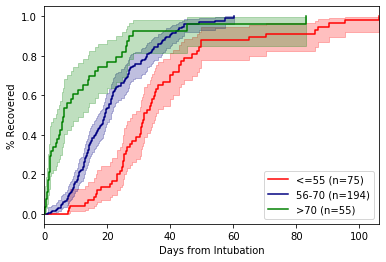

In [66]:
# plt.figure()
fig, ax = plt.subplots(1,1, figsize=(6, 4))
pao2_threshold = 55 # for strata
max_q_vals = []
color = ['red', 'navy', 'green']

min_pao2 = 0
max_pao2 = 55
data_selection = data.query(f"PaO2_minimum >= {min_pao2} & PaO2_minimum <= {max_pao2}")
n1 = data_selection.shape[0]
kmf = KaplanMeierFitter()
kmf.fit(durations = data_selection['Time_To_ROC'], event_observed = data_selection['ROC_Binary'])
kmf.plot_cumulative_density(at_risk_counts=False, color=color[0], ax=ax)

min_pao2 = 55
max_pao2 = 70
data_selection = data.query(f"PaO2_minimum > {min_pao2} & PaO2_minimum <= {max_pao2}")
n2 = data_selection.shape[0]
kmf = KaplanMeierFitter()
kmf.fit(durations = data_selection['Time_To_ROC'], event_observed = data_selection['ROC_Binary'])
kmf.plot_cumulative_density(at_risk_counts=False, color=color[1], ax=ax)

min_pao2 = 70
max_pao2 = 300
data_selection = data.query(f"PaO2_minimum > {min_pao2} & PaO2_minimum < {max_pao2}")
n3 = data_selection.shape[0]
kmf = KaplanMeierFitter()
kmf.fit(durations = data_selection['Time_To_ROC'], event_observed = data_selection['ROC_Binary'])
kmf.plot_cumulative_density(at_risk_counts=False, color=color[2], ax=ax)


plt.legend([f'<=55 (n={n1})', f'56-70 (n={n2})', f'>70 (n={n3})'])
plt.xlabel('Days from Intubation')
plt.ylabel('% Recovered')

plt.savefig(f'minimum_hypoxia_quintiles_{roc_definition}_{hypoxia_timespan}_day7{day_7_alive_and_comatose}.svg')
plt.savefig(f'minimum_hypoxia_quintiles_{roc_definition}_{hypoxia_timespan}_day7{day_7_alive_and_comatose}.tiff', dpi=400)

In [67]:
n1+n2+n3

324

In [68]:
data[pd.isna(data.PaO2_minimum)]

,index,PatientID,AdmissionDTS,DischargeDTS,First_ICU_Admit,First_ICU_Discharge,Second_ICU_Admit,Second_ICU_Discharge,Third_ICU_Admit,Third_ICU_Discharge,...,PaO2_65,Cat_Days_PaO2_65,PaO2_66,Cat_Days_PaO2_66,PaO2_67,Cat_Days_PaO2_67,PaO2_68,Cat_Days_PaO2_68,PaO2_69,Cat_Days_PaO2_69
24,27,Z10609296,2020-05-21 03:33:00,2020-05-28 16:20:00,2020-05-21 03:27:00,2020-05-22 13:41:00,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
71,76,Z11595750,2020-06-06 05:27:00,2020-06-14 12:36:00,2020-06-06 05:27:00,2020-06-09 17:02:00,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
102,108,Z12566182,2020-04-13 16:43:00,2020-04-13 20:40:00,2020-04-13 19:58:00,2020-04-13 20:40:00,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
127,134,Z14341766,2020-06-25 13:02:00,2020-07-07 14:47:00,2020-06-25 13:31:00,2020-06-28 18:08:00,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
195,205,Z17760519,2020-04-14 02:17:00,2020-04-29 12:34:00,2020-04-14 04:02:00,2020-04-15 13:05:00,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
275,288,Z7825622,2020-04-18 20:51:00,2020-04-23 16:22:00,2020-04-18 21:06:00,2020-04-23 16:22:00,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


AttributeError: 'DataFrame' object has no attribute 'ROC_LOC'

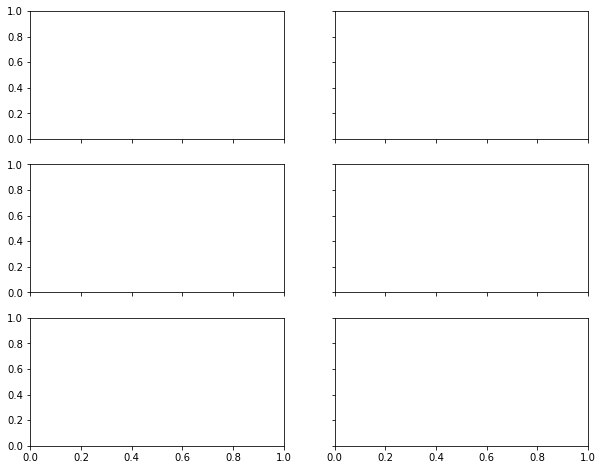

In [34]:
roc_definitions = ['ROClast', 'ROCfirst']
hypoxia_timespans = ['PaO2admission', 'PaO2intubation', 'PaO2intubation14days']
min_days_to_recoveries = [0, 7]

roc_definition = 'ROClast'

fig, ax = plt.subplots(3,2, figsize=(10,8), sharex=True, sharey=True)
color = ['red', 'orange', 'navy', 'dodgerblue', 'green']
ax = ax.flatten()
i_axis = -1

manual_q_vals_min = [0, 54, 59, 62, 67] # since quintiles are slightly different for different versions, fix the q-values here.
manual_q_vals_max = [54, 59, 62, 67, 200]

for hypoxia_timespan, min_days_to_recovery in list(itertools.product(hypoxia_timespans, min_days_to_recoveries)):
    i_axis += 1
    
    data = pd.read_csv(f'cohort_hypoxia_roc_{roc_definition}_{hypoxia_timespan}.csv', sep=';')
    data = data.loc[data.ROC_LOC == 1] # have to have Loss Of Consciousness

    max_q_vals = []
    # Kaplan Meier Fitter
    # kmf.fit(durations = data['Time_To_ROC'], event_observed = data['ROC_Binary'])
    for iq, q in enumerate([0.2, 0.4, 0.6, 0.8, 1]):

        data_selection = data.query(f"Time_To_ROC >= {min_days_to_recovery}")

        if 0: # compute values
            min_q_val = data_selection.PaO2_minimum.quantile(q - 0.2)
            max_q_val = data_selection.PaO2_minimum.quantile(q)
            if q == 0.2:
                min_q_val = 0
            elif q == 1:
                max_q_val = 1000
            max_q_vals.append(data_selection.PaO2_minimum.quantile(q).round(1))

        else: # use fixed values:
            min_q_val = manual_q_vals_min[iq]
            max_q_val = manual_q_vals_max[iq]
            max_q_vals = manual_q_vals_max
            
        kmf = KaplanMeierFitter()

        data_selection = data_selection.query(f"PaO2_minimum >= {min_q_val} & PaO2_minimum < {max_q_val}")
        kmf.fit(durations = data_selection['Time_To_ROC'], event_observed = data_selection['ROC_Binary'])

        kmf.plot_cumulative_density(at_risk_counts=False, color=color[iq], ax=ax[i_axis])

        ax[i_axis].legend('', frameon=False)

#         ax[i_axis].legend(max_q_vals)
        ax[i_axis].set_xlabel('Days from Intubation')
        ax[i_axis].set_ylabel('% Recovered')

ax[0].legend(max_q_vals, bbox_to_anchor=(0.4, 1.6), ncol=2, frameon=False, title='Minimum PaO2 below')

ax[0].text(0.5, 1.1, 'Min. Days to Recover = 0', horizontalalignment='center', transform=ax[0].transAxes)
ax[1].text(0.5, 1.1, 'Min. Days to Recover = 7', horizontalalignment='center', transform=ax[1].transAxes)

ax[0].text(-0.25, 0.5, 'PaO2 from Admission', verticalalignment='center', transform=ax[0].transAxes, rotation=90)
ax[2].text(-0.25, 0.5, 'PaO2 from Intubation', verticalalignment='center', transform=ax[2].transAxes, rotation=90)
ax[4].text(-0.25, 0.5, 'PaO2 from Intubation\n<=14 days', verticalalignment='center', transform=ax[4].transAxes, rotation=90)

plt.tight_layout()

plt.subplots_adjust(left=0.13)

plt.savefig(f'minimum_hypoxia_quintiles_{roc_definition}_all_timespans.svg')
plt.savefig(f'minimum_hypoxia_quintiles_{roc_definition}_all_timespans.tiff', dpi=400)



In [ ]:
roc_definitions = ['ROClast', 'ROCfirst']
hypoxia_timespans = ['PaO2intubation', 'PaO2intubation14days', 'PaO2admission']
min_days_to_recoveries = [0] #  7]

roc_definition = 'ROClast'

fig, ax = plt.subplots(1,2, figsize=(8,4), sharex=True, sharey=True)
color = ['red', 'orange', 'navy', 'dodgerblue', 'green']
i_axis = -1

manual_q_vals_min = [0, 54, 59, 62, 67] # since quintiles are slightly different for different versions, fix the q-values here.
manual_q_vals_max = [54, 59, 62, 67, 200]

for hypoxia_timespan, min_days_to_recovery in list(itertools.product(hypoxia_timespans, min_days_to_recoveries)):
    i_axis += 1
    
    data = pd.read_csv(f'cohort_hypoxia_roc_{roc_definition}_{hypoxia_timespan}.csv', sep=';')
    data = data.loc[data.ROC_LOC == 1] # have to have Loss Of Consciousness

    max_q_vals = []
    # Kaplan Meier Fitter
    # kmf.fit(durations = data['Time_To_ROC'], event_observed = data['ROC_Binary'])
    for iq, q in enumerate([0.2, 0.4, 0.6, 0.8, 1]):

        data_selection = data.query(f"Time_To_ROC >= {min_days_to_recovery}")

        if 0: # compute values
            min_q_val = data_selection.PaO2_minimum.quantile(q - 0.2)
            max_q_val = data_selection.PaO2_minimum.quantile(q)
            if q == 0.2:
                min_q_val = 0
            elif q == 1:
                max_q_val = 1000
            max_q_vals.append(data_selection.PaO2_minimum.quantile(q).round(1))

        else: # use fixed values:
            min_q_val = manual_q_vals_min[iq]
            max_q_val = manual_q_vals_max[iq]
            max_q_vals = manual_q_vals_max
            
        kmf = KaplanMeierFitter()

        data_selection = data_selection.query(f"PaO2_minimum >= {min_q_val} & PaO2_minimum < {max_q_val}")
        kmf.fit(durations = data_selection['Time_To_ROC'], event_observed = data_selection['ROC_Binary'])

        kmf.plot_cumulative_density(at_risk_counts=False, ci_show=False, color=color[i_axis], ax=ax[0])

        ax[0].legend('', frameon=False)

#         ax[i_axis].legend(max_q_vals)
        ax[0].set_xlabel('Days from Intubation')
        ax[0].set_ylabel('% Recovered')

#### sec

roc_definitions = ['ROClast', 'ROCfirst']
# hypoxia_timespans = ['PaO2admission', 'PaO2intubation', 'PaO2intubation14days']
min_days_to_recoveries = [7]
roc_definition = 'ROClast'

i_axis = -1

manual_q_vals_min = [0, 54, 59, 62, 67] # since quintiles are slightly different for different versions, fix the q-values here.
manual_q_vals_max = [54, 59, 62, 67, 200]

for hypoxia_timespan, min_days_to_recovery in list(itertools.product(hypoxia_timespans, min_days_to_recoveries)):
    i_axis += 1
    print(color[i_axis])
    data = pd.read_csv(f'cohort_hypoxia_roc_{roc_definition}_{hypoxia_timespan}.csv', sep=';')
    data = data.loc[data.ROC_LOC == 1] # have to have Loss Of Consciousness

    max_q_vals = []
    # Kaplan Meier Fitter
    # kmf.fit(durations = data['Time_To_ROC'], event_observed = data['ROC_Binary'])
    for iq, q in enumerate([0.2, 0.4, 0.6, 0.8, 1]):

        data_selection = data.query(f"Time_To_ROC >= {min_days_to_recovery}")

        if 0: # compute values
            min_q_val = data_selection.PaO2_minimum.quantile(q - 0.2)
            max_q_val = data_selection.PaO2_minimum.quantile(q)
            if q == 0.2:
                min_q_val = 0
            elif q == 1:
                max_q_val = 1000
            max_q_vals.append(data_selection.PaO2_minimum.quantile(q).round(1))

        else: # use fixed values:
            min_q_val = manual_q_vals_min[iq]
            max_q_val = manual_q_vals_max[iq]
            max_q_vals = manual_q_vals_max
            
        kmf = KaplanMeierFitter()

        data_selection = data_selection.query(f"PaO2_minimum >= {min_q_val} & PaO2_minimum < {max_q_val}")
        kmf.fit(durations = data_selection['Time_To_ROC'], event_observed = data_selection['ROC_Binary'])

        kmf.plot_cumulative_density(at_risk_counts=False, ci_show=False, color=color[i_axis], ax=ax[1])

        ax[1].legend('', frameon=False)

#         ax[i_axis].legend(max_q_vals)
        ax[1].set_xlabel('Days from Intubation')
        ax[1].set_ylabel('% Recovered')

import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='red', label='')
orange_patch = mpatches.Patch(color='orange', label='')
navy_patch = mpatches.Patch(color='navy', label='')

ax[1].legend(handles=[red_patch, orange_patch, navy_patch], labels=hypoxia_timespans)

# ax[0].text(0.5, 1.1, 'Min. Days to Recover = 0', horizontalalignment='center', transform=ax[0].transAxes)
# ax[1].text(0.5, 1.1, 'Min. Days to Recover = 7', horizontalalignment='center', transform=ax[1].transAxes)

# ax[0].text(-0.25, 0.5, 'PaO2 from Admission', verticalalignment='center', transform=ax[0].transAxes, rotation=90)
# ax[2].text(-0.25, 0.5, 'PaO2 from Intubation', verticalalignment='center', transform=ax[2].transAxes, rotation=90)
# ax[4].text(-0.25, 0.5, 'PaO2 from Intubation\n<=14 days', verticalalignment='center', transform=ax[4].transAxes, rotation=90)

plt.tight_layout()

plt.savefig(f'hypoxia_covid_comparison_different_PaO2values.svg')
plt.savefig(f'hypoxia_covid_comparison_different_PaO2values.tiff', dpi=400)

In [35]:
kmf.event_table.head()

,removed,observed,censored,entrance,at_risk
event_at,,,,,
0.000000,0,0,0,31,31
0.101389,1,0,1,0,31
0.240278,1,1,0,0,30
0.281250,1,0,1,0,29
0.694444,1,1,0,0,28


In [36]:
kmf.event_table.censored

event_at
0.000000     0
0.101389     1
0.240278     0
0.281250     1
0.694444     0
1.000000     1
1.068056     0
1.253472     1
1.284722     1
1.450694     0
1.452083     1
3.343750     1
4.050694     0
4.954861     0
5.062500     1
5.522222     0
6.024306     1
6.388194     0
10.711806    0
14.229167    0
16.040278    0
18.696528    1
19.916667    0
22.621528    0
24.793056    0
25.822222    0
26.392361    0
26.789583    0
26.958333    0
28.085417    0
30.180556    1
83.016667    0
Name: censored, dtype: int64

In [57]:
kmf.plot_cumulative_density?

Signature: kmf.plot_cumulative_density(**kwargs)
Docstring:
Plots a pretty figure of the cumulative density function.

Matplotlib plot arguments can be passed in inside the kwargs.

Parameters
-----------
show_censors: bool
    place markers at censorship events. Default: False
censor_styles: bool
    If show_censors, this dictionary will be passed into the plot call.
ci_alpha: bool
    the transparency level of the confidence interval. Default: 0.3
ci_force_lines: bool
    force the confidence intervals to be line plots (versus default shaded areas). Default: False
ci_show: bool
    show confidence intervals. Default: True
ci_legend: bool
    if ci_force_lines is True, this is a boolean flag to add the lines' labels to the legend. Default: False
at_risk_counts: bool
    show group sizes at time points. See function ``add_at_risk_counts`` for details. Default: False
loc: slice
    specify a time-based subsection of the curves to plot, ex:

    >>> model.plot(loc=slice(0.,10.))

    wil